In [1]:
from pathlib import Path
from test_vectorized import read_audio_chunk, plot_pr_curve, load_threshold, load_template_segment, batch_stft_windows, dtw_costs_vectorized, load_raven_selection_table, compute_pr_curve, compute_average_precision, match_detections, plot_detection_spectrograms, get_exclusion_intervals, get_exclusion_mask
import json
import numpy as np


DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

In [2]:
st_temps = RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json"
mt_temps = RESULTS_29 / "20230429_Templates_20230429_102841_multi_tone_templates.json"
bt_temps = RESULTS_29 / "20230429_Templates_20230429_102841_burst_tonal_templates.json"

#load template data from .json file
with open(st_temps) as f:
    st_templates = json.load(f)

with open(mt_temps) as f:
    mt_templates = json.load(f)

with open(bt_temps) as f:
    bt_templates = json.load(f)

st_templates = st_templates[:5]
mt_templates = mt_templates[:5]
bt_templates = bt_templates[:5]

st_stfts = [load_template_segment(t, 1000) for t in st_templates]
mt_stfts = [load_template_segment(t, 1000) for t in mt_templates]
bt_stfts = [load_template_segment(t, 1000) for t in bt_templates]

Load thresholds

In [3]:
st = load_threshold(file_label = "20230429_Templates", 
               call_type = "single_tone", 
               results_dir = RESULTS_29)

st_threshold = st["threshold"]

mt = load_threshold(file_label = "20230429_Templates", 
               call_type = "multi_tone", 
               results_dir = RESULTS_29)

mt_threshold = mt["threshold"]

bt = load_threshold(file_label = "20230429_Templates", 
               call_type = "burst_tonal", 
               results_dir = RESULTS_29)

bt_threshold = bt["threshold"]

print(f"Single Tone Threshold: {st_threshold}")
print(f"Multi Tone Threshold: {mt_threshold}")
print(f"Burst Tonal Threshold: {bt_threshold}")

Single Tone Threshold: 0.13991060804627278
Multi Tone Threshold: 0.13054360422863484
Burst Tonal Threshold: 0.14558571279709498


Load 72 hour audio in 1 hour segments

In [ ]:
all_detected_t = []       # global list, accumulates across all hours
all_detected_labels = []  # optional: keep track of call type too
all_scores = []      # NEW: raw mean_cost for every window, every hour
all_labels_all = []  # NEW: best-matching call type for every window (even if not triggered)
all_times_all = []   # NEW: global time for every window

ground_truth = load_raven_selection_table(DATA_22 / "2023-04-22T17-13-01_000_00070.txt")
td_intervals = get_exclusion_intervals(ground_truth, exclude_labels=("td",), pad=0.1)

for i in range(72):
    #print(f"Processing hour {i+1} of 72")
    #load 1 hour of audio and resample to fs = 1000Hz
    f_s, audio_array = read_audio_chunk(DATA_22 / "20230422_171301.wav", i, duration_hour=1.0, fs_new=1000)

    #split audio into windows and store in a vector and calculate STFT for each window
    f_win, t_win,Zxx_window = batch_stft_windows(audio_array, 
                                                window_len = int(0.15*1000), 
                                                step_len = int(0.15*1000/2), 
                                                fs_new = f_s, 
                                                framelength = int(f_s * 0.128), 
                                                noverlap = int(int(f_s * 0.128) * 0.75))

    n_windows = Zxx_window.shape[0]
    window_times_global = np.arange(n_windows) * 0.075 + i * 3600

    keep = get_exclusion_mask(window_times_global, window_len=0.15, exclude_intervals=td_intervals)

    Zxx_window = Zxx_window[keep]
    window_times_global = window_times_global[keep]

    costs_st, costs_mt, costs_bt = dtw_costs_vectorized(st_stfts, 
                                                    mt_stfts, 
                                                    bt_stfts, 
                                                    n_templates = 5, 
                                                    audio_segment = Zxx_window)  

    '''n_windows = Zxx_window.shape[0]
    call_detected = np.zeros(n_windows, dtype=bool)
    call_labels = np.full(n_windows, "", dtype=object)

    for costs_list, threshold, label in [(costs_st, st_threshold, "st"),
                                        (costs_mt, mt_threshold, "mt"),
                                        (costs_bt, bt_threshold, "bt")]:
        costs_arr = np.vstack(costs_list)        # shape: (n_templates, n_windows)
        below_thresh = costs_arr < threshold     # shape: (n_templates, n_windows)
        triggered = below_thresh.any(axis=0)     # shape: (n_windows,) -- True if ANY template hit

        # only tag windows that haven't already been tagged by an earlier call type
        newly_triggered = triggered & ~call_detected
        call_labels[newly_triggered] = label
        call_detected |= triggered'''
    # compute votes/mean_cost for all three call types first, then decide winner per window
    results = {}
    for costs_list, threshold, label in [(costs_st, st_threshold, "st"),
                                        (costs_mt, mt_threshold, "mt"),
                                        (costs_bt, bt_threshold, "bt")]:

        costs_arr = np.vstack(costs_list)
        n_templates = costs_arr.shape[0]
        votes = (costs_arr < threshold).sum(axis=0)
        mean_cost = costs_arr.mean(axis=0)
        triggered = votes >= np.ceil(0.6 * n_templates)
        results[label] = (triggered, mean_cost)

    n_windows = Zxx_window.shape[0]
    call_detected = np.zeros(n_windows, dtype=bool)
    call_labels = np.full(n_windows, "", dtype=object)
    best_cost = np.full(n_windows, np.inf)
    best_cost_all = np.full(n_windows, np.inf)
    best_label_all = np.full(n_windows, "", dtype=object)

    for label, (triggered, mean_cost) in results.items():
        all_time_better = mean_cost < best_cost_all
        best_label_all[all_time_better] = label
        best_cost_all[all_time_better] = mean_cost[all_time_better]

        triggered_better = triggered & (mean_cost < best_cost)
        call_labels[triggered_better] = label
        best_cost[triggered_better] = mean_cost[triggered_better]
        call_detected |= triggered

    print(f"Processing hour {i+1} of 72: {call_detected.sum()} / {n_windows} windows flagged as calls")

    window_times_global = np.arange(n_windows) * 0.075 + i * 3600
    all_scores.extend(best_cost_all.tolist())
    all_labels_all.extend(best_label_all.tolist())
    all_times_all.extend(window_times_global.tolist())

    detected = np.where(call_detected)[0]
    detected_t = detected*75/1000
    detected_t_global = detected_t + i*3600
    all_detected_t.extend(detected_t_global.tolist())
    all_detected_labels.extend(call_labels[detected].tolist())

# after the loop, convert to arrays for downstream use
all_detected_t = np.array(all_detected_t)
all_detected_labels = np.array(all_detected_labels, dtype=object)
all_scores = np.array(all_scores)
all_labels_all = np.array(all_labels_all, dtype=object)
all_times_all = np.array(all_times_all)

Processing hour 1 of 72: 28 / 47999 windows flagged as calls
Processing hour 2 of 72: 3 / 47999 windows flagged as calls
Processing hour 3 of 72: 4 / 47999 windows flagged as calls
Processing hour 4 of 72: 1 / 47999 windows flagged as calls
Processing hour 5 of 72: 1 / 47999 windows flagged as calls
Processing hour 6 of 72: 2 / 47999 windows flagged as calls
Processing hour 7 of 72: 1 / 47999 windows flagged as calls
Processing hour 8 of 72: 1 / 47999 windows flagged as calls
Processing hour 9 of 72: 0 / 47999 windows flagged as calls
Processing hour 10 of 72: 1 / 47999 windows flagged as calls
Processing hour 11 of 72: 3 / 47999 windows flagged as calls
Processing hour 12 of 72: 2 / 47999 windows flagged as calls
Processing hour 13 of 72: 1 / 47999 windows flagged as calls
Processing hour 14 of 72: 15 / 47999 windows flagged as calls
Processing hour 15 of 72: 25 / 47999 windows flagged as calls
Processing hour 16 of 72: 3 / 47999 windows flagged as calls
Processing hour 17 of 72: 10 /

Merge Consecutive detected windows

In [5]:
step = 0.075       # step_len in seconds (150ms window, 50% overlap -> 75ms step)
window_len = 0.15  # window length in seconds
tol = 1e-6         # floating point tolerance

combined_calls = []  # list of (start_time, end_time, label)

if len(all_detected_t) > 0:
    run_start = all_detected_t[0]
    run_end   = all_detected_t[0]
    run_label = all_detected_labels[0]

    for t, label in zip(all_detected_t[1:], all_detected_labels[1:]):
        gap = t - run_end
        is_consecutive = np.isclose(gap, step, atol=tol)

        if is_consecutive and label == run_label:
            # extend the current run
            run_end = t
        else:
            # close out the current run, start a new one
            combined_calls.append((run_start, run_end + window_len, run_label))
            run_start = t
            run_end = t
            run_label = label

    # don't forget to flush the last run after the loop ends
    combined_calls.append((run_start, run_end + window_len, run_label))

print(f"Merged {len(all_detected_t)} raw window detections into {len(combined_calls)} calls")

Merged 17667 raw window detections into 5889 calls


PR curve / Ground truthing

In [13]:
ground_truth = load_raven_selection_table(DATA_22 / "2023-04-22T17-13-01_000_00070.txt")
exclude_labels = ("td",)
ground_truth_eval = [g for g in ground_truth if g["label"] not in exclude_labels]


In [14]:
precision, recall, thresholds = compute_pr_curve(
    all_times_all, all_scores, all_labels_all, ground_truth_eval,
    step=step, window_len=window_len, n_thresholds=20, require_label_match=False
)


In [15]:
ap = compute_average_precision(precision, recall)
print(f"Average Precision: {ap:.4f}")

idx = np.argmin(np.abs(thresholds - mt_threshold))
print(f"At your chosen mt_threshold: precision={precision[idx]:.3f}, recall={recall[idx]:.3f}")

tp, fp, fn, false_positive_detections, false_negative_gts = match_detections(combined_calls, ground_truth_eval, require_label_match=False)
precision_point = tp / (tp + fp) if (tp + fp) > 0 else 1.0
recall_point = tp / (tp + fn) if (tp + fn) > 0 else 0.0
print(f"combined_calls: precision={precision_point:.3f}, recall={recall_point:.3f}")

Average Precision: 0.7132
At your chosen mt_threshold: precision=0.466, recall=0.936
combined_calls: precision=0.272, recall=0.978


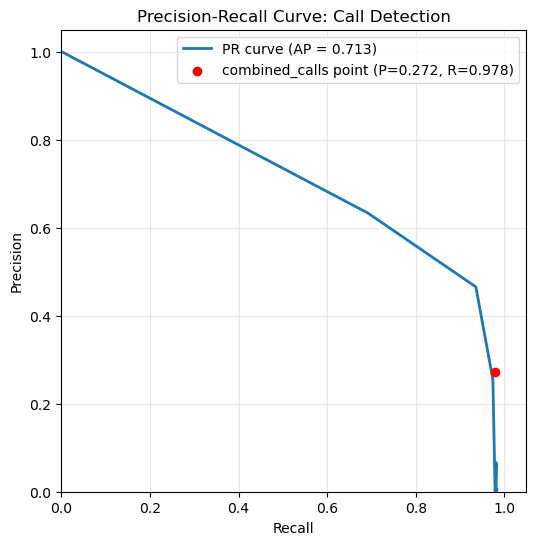

In [16]:
plot_pr_curve(precision, recall, ap=ap, marked_point=(precision_point, recall_point))

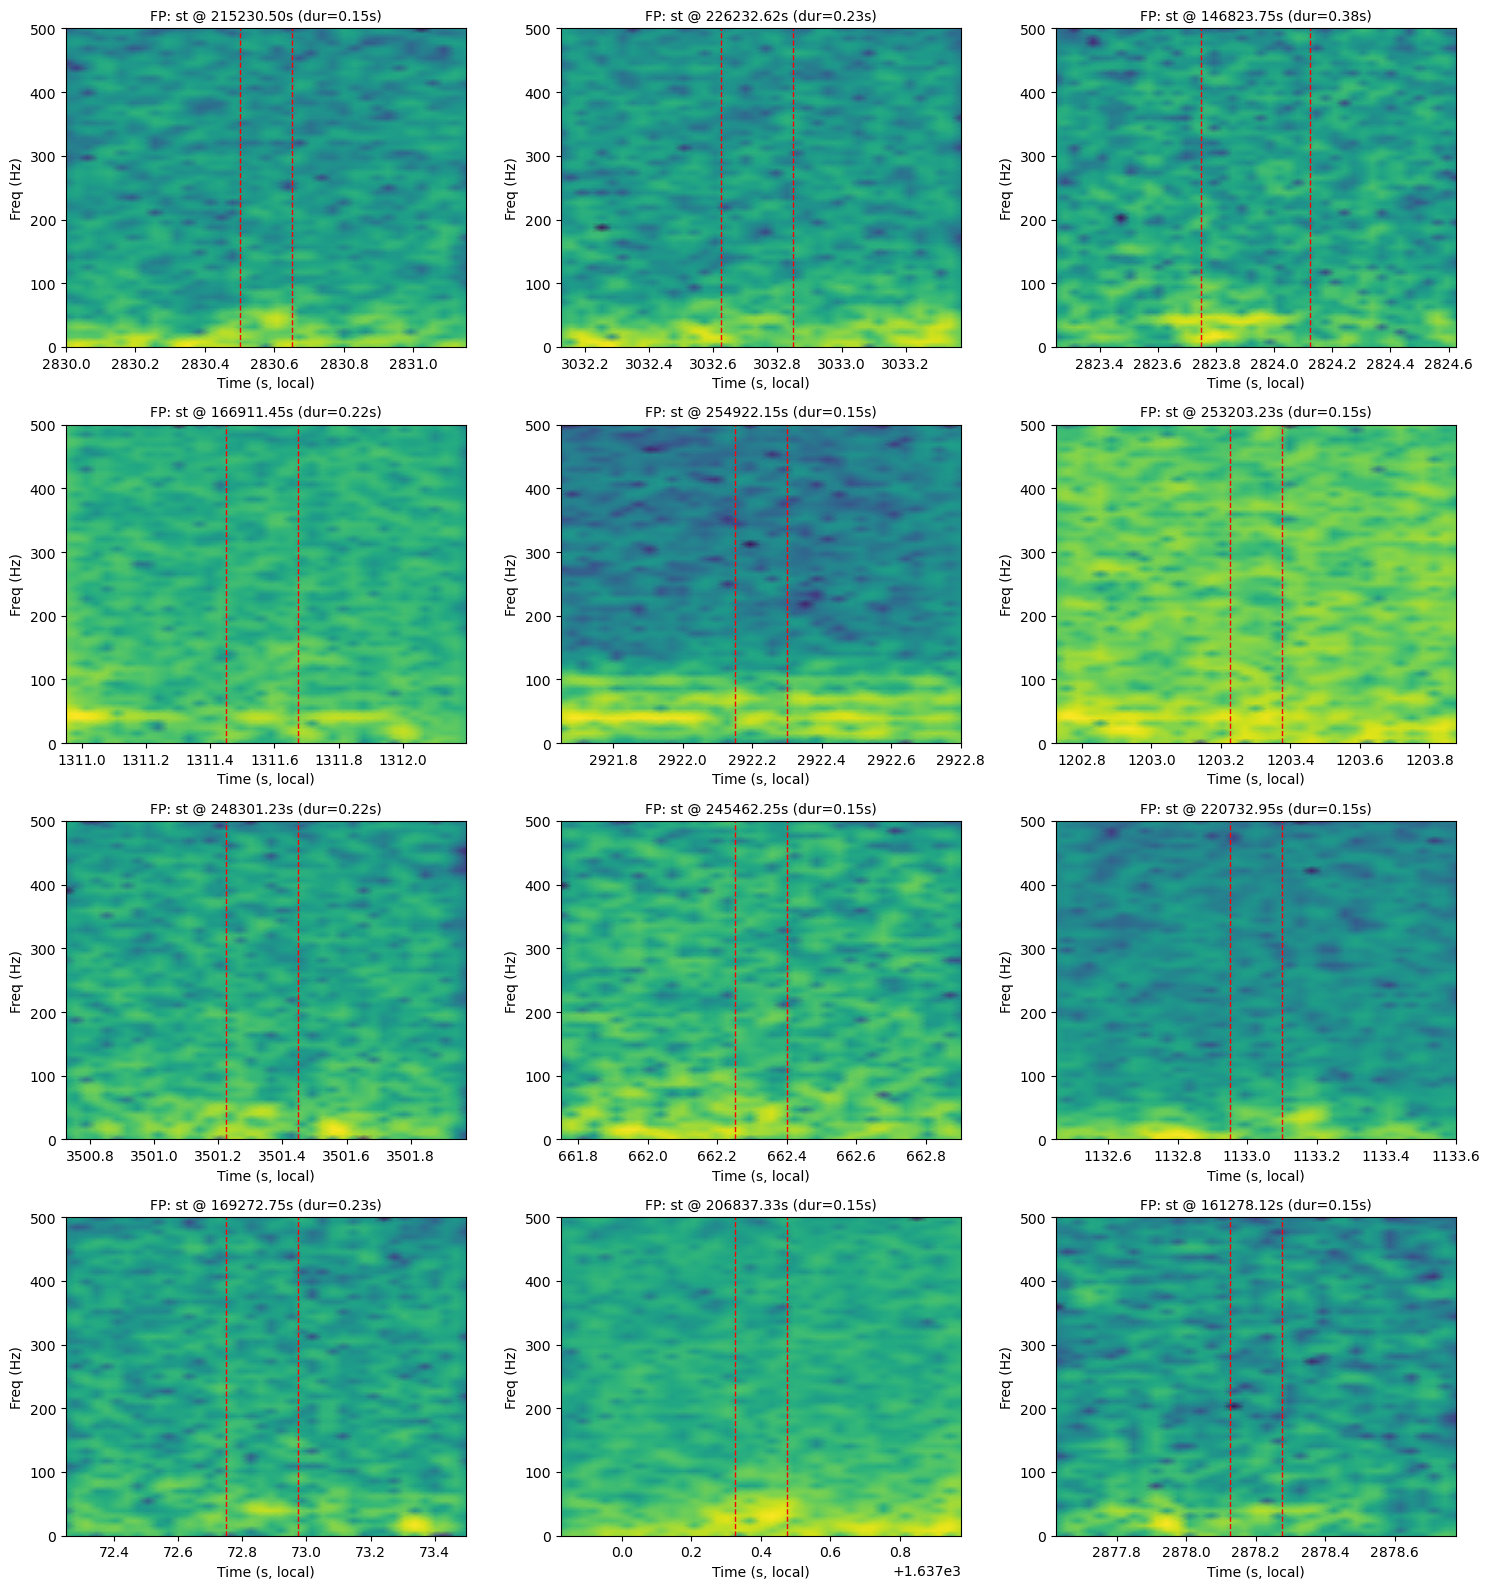

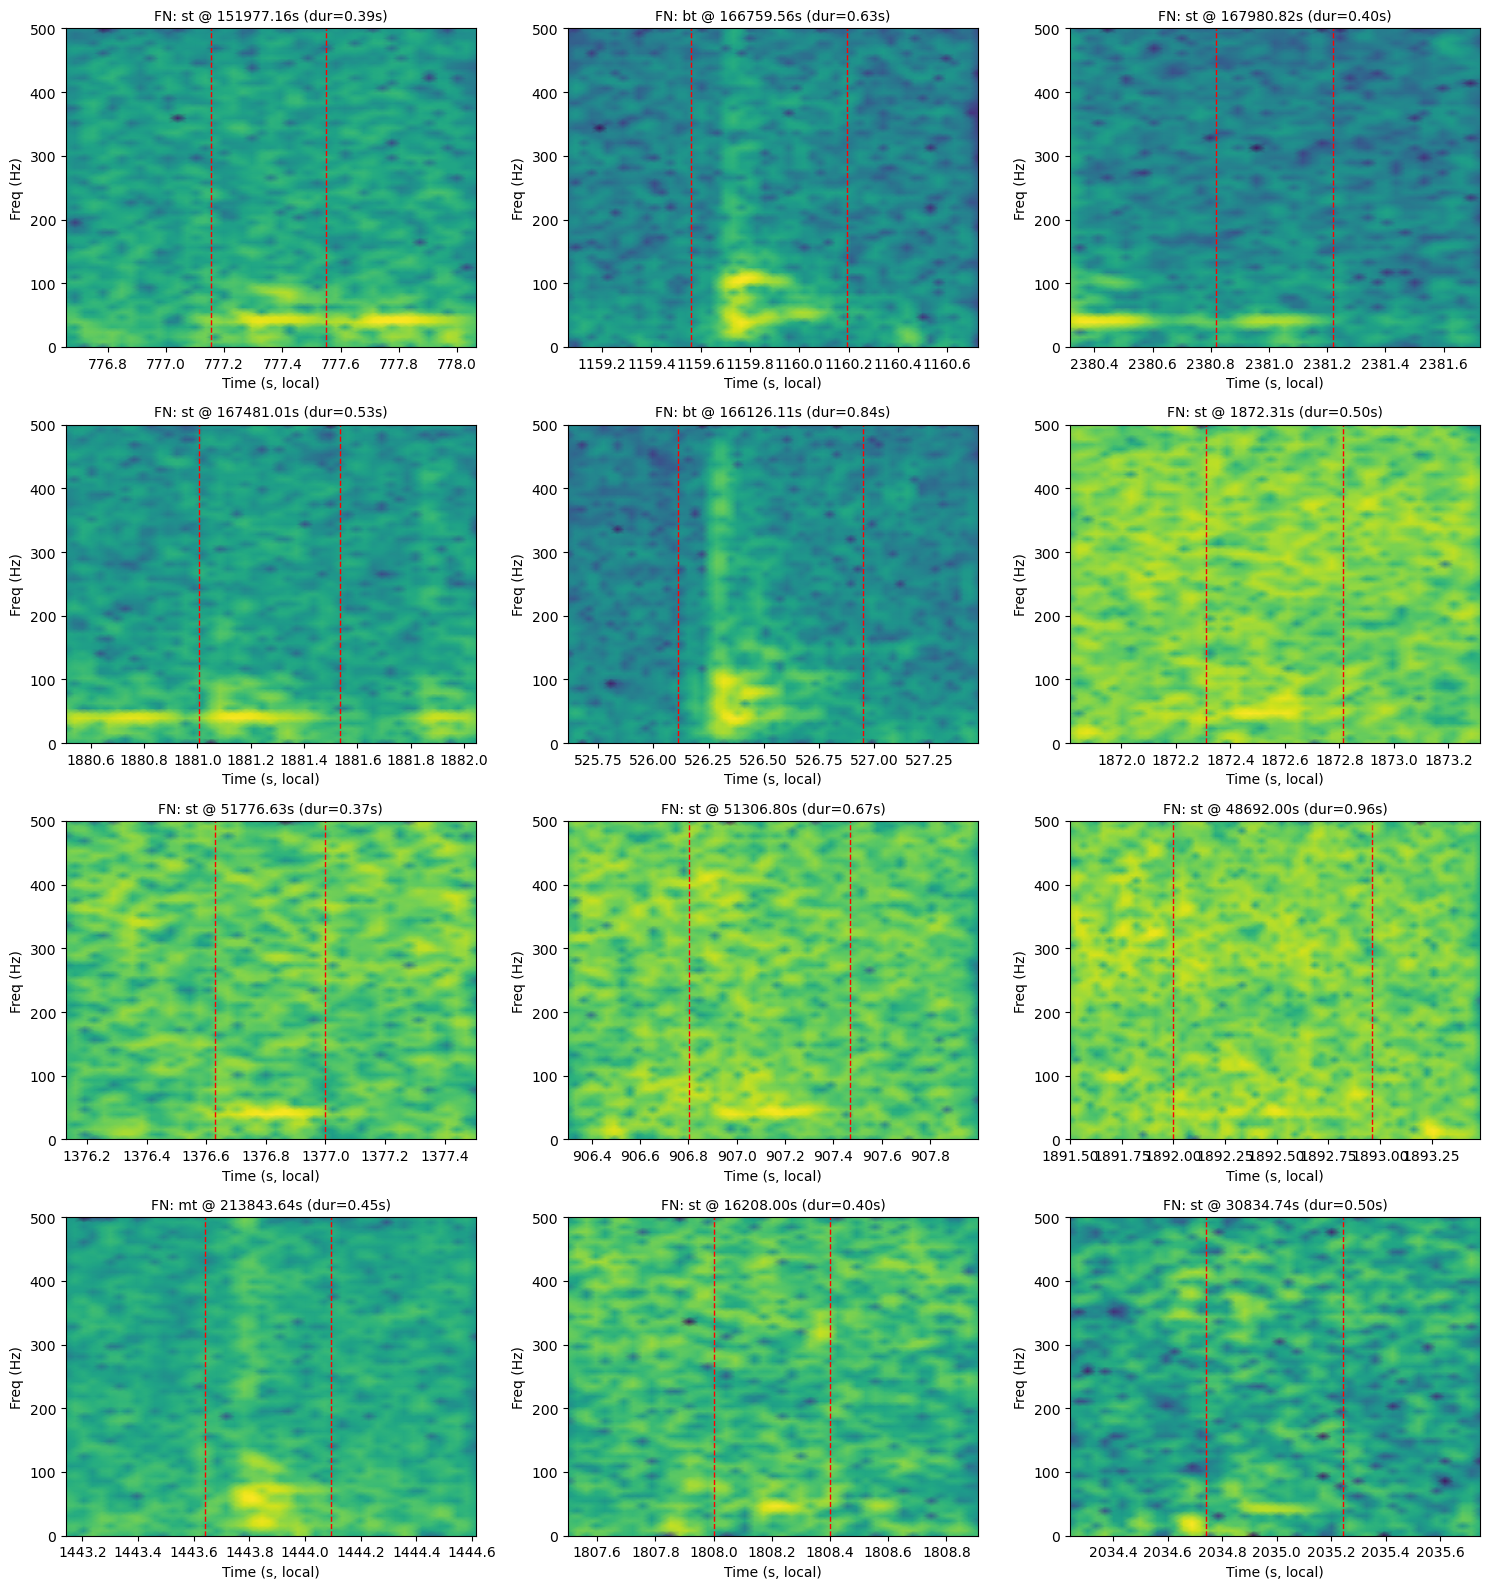

In [17]:
# plot a random sample of false positives
plot_detection_spectrograms(
    false_positive_detections,
    DATA_22 / "20230422_171301.wav",
    fs_new=1000,
    n_examples=12,
    title_prefix="FP"
)

# you can also inspect false negatives (missed calls) the same way
fn_as_tuples = [(g["start"], g["end"], g["label"]) for g in false_negative_gts]
plot_detection_spectrograms(
    fn_as_tuples,
    DATA_22 / "20230422_171301.wav",
    fs_new=1000,
    n_examples=12,
    title_prefix="FN"
)